In [14]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt
import vl_convert

In [15]:
# file
df = pd.read_csv("Data Model - Pizza Sales.csv")

In [16]:
# create datetime, hour, day
df["order_datetime"] = pd.to_datetime(
    df["order_date"] + " " + df["order_time"]
)
df["hour"] = df["order_datetime"].dt.hour
df["day_name"] = df["order_datetime"].dt.day_name()

# day and size order
size_order = ["S", "M", "L", "XL", "XXL"]
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df["pizza_size"] = pd.Categorical(df["pizza_size"], categories=size_order, ordered=True)
df["day_name"] = pd.Categorical(df["day_name"], categories=day_order, ordered=True)



/var/folders/kb/_sjc1wx967d_5vr4grv3mzvw0000gn/T/ipykernel_13449/1050675449.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = df.pivot_table(


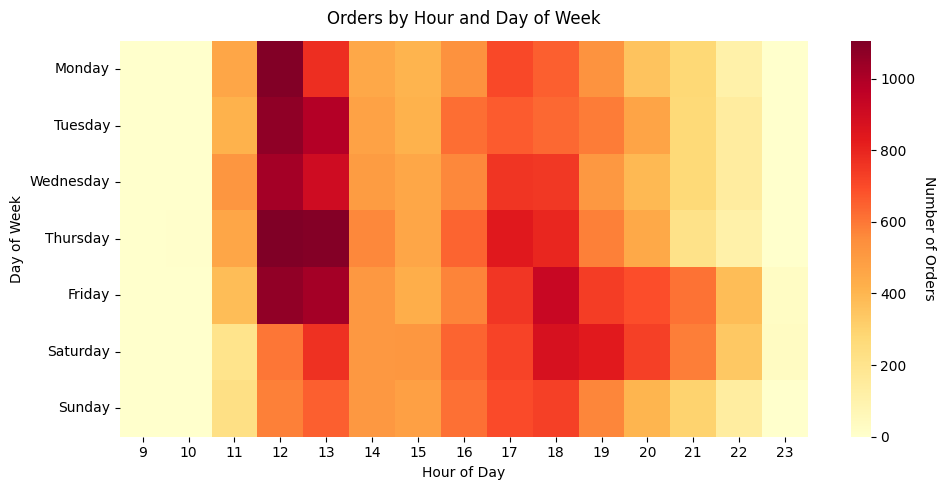

saved: heatmap_orders.jpg


In [17]:

# figure 1: heatmap of orders
heat = df.pivot_table(
    index="day_name",
    columns="hour",
    values="order_id",
    aggfunc="count"
)

plt.figure(figsize=(10, 5))
ax = sns.heatmap(heat, cmap="YlOrRd")

# add titles
plt.title("Orders by Hour and Day of Week", pad=12)
cbar = ax.collections[0].colorbar
cbar.set_label("Number of Orders", rotation=270, labelpad=15)

# add axes labels
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.tight_layout()
plt.savefig("heatmap_orders.jpg", dpi=300)
plt.show()
print("saved: heatmap_orders.jpg")


In [18]:
# figure 2: size contribution
sales = df.copy()
sales_small = sales.drop_duplicates(subset=["order_details_id"])

vis2 = (
    alt.Chart(sales_small)
    .mark_bar()
    .encode(
        x=alt.X("pizza_category:N", title="Category"),
        y=alt.Y("sum(total_price):Q", title="Total Revenue ($)"),
        color=alt.Color(
            "pizza_size:O",
            title="Size",
            scale=alt.Scale(scheme="yelloworangered")
        ),
        order=alt.Order("pizza_size:O")
    )
    .properties(width=500, height=350,
                title="Figure 2: Size Contribution to Total Sales by Category")
)

vis2.save("fig2_size_contribution_chart.html")
vis2.save("size_contribution_by_sales.png")
print("saved: fig2_size_contribution_chart.html, size_contribution_by_sales.png")


saved: fig2_size_contribution_chart.html, size_contribution_by_sales.png


In [19]:

# figure 3: top pizzas
clean_sales = sales.drop_duplicates(subset=["order_details_id"])

popularity = (
    clean_sales.groupby("pizza_name")
    .size()
    .reset_index(name="order_count")
)

revenue = (
    clean_sales.groupby("pizza_name")
    .agg({"total_price": "sum"})
    .reset_index()
)

metrics = revenue.merge(popularity, on="pizza_name", how="left")

sort_choice = alt.param(
    name="sort_by",
    bind=alt.binding_select(options=["Revenue", "Popularity"], name="Sort by: "),
    value="Revenue"
)

# customize graph
vis3 = (
    alt.Chart(metrics)
    .add_params(sort_choice)
    .transform_calculate(
        metric="sort_by === 'Revenue' ? datum.total_price : datum.order_count"
    )
    .transform_window(
        rank="rank(metric)",
        sort=[{"field": "metric", "order": "descending"}]
    )
    .transform_filter("datum.rank <= 5")
    .mark_bar(color="#D95F02")
    .encode(
        x=alt.X("total_price:Q", title="Revenue ($)"),
        y=alt.Y("pizza_name:N", sort="-x", title="Pizza Name"),
        tooltip=["pizza_name", "total_price", "order_count"]
    )
    .properties(width=500, height=350, title="Figure 3: Top 5 Pizzas by Revenue")
)

# save files
vis3.save("fig3_top_pizzas_chart.html")
vis3.save("top_pizza_by_revenue.png")

# print
print("Saved: fig3_top_pizzas_chart.html, top_pizza_by_revenue.png")

Saved: fig3_top_pizzas_chart.html, top_pizza_by_revenue.png
